# 🎬 Movie Recommendation System — MovieLens
## Content-Based Recommender with Feature Engineering & Popularity-Aware Ranking
**Author:** Dmitry

---

### Pipeline Overview

| Step | Description |
|------|-------------|
| **1** | Data Loading & Exploration |
| **2** | Data Cleaning & Preprocessing |
| **3** | Feature Engineering |
| **4** | Content-Based Similarity (TF-IDF + Cosine) |
| **5** | Popularity-Aware Ranking |
| **6** | Hybrid Recommendation Engine |
| **7** | Evaluation & Visualization |
| **8** | Interactive Demo Widget |

### Hybrid Scoring Formula

$$\text{Score} = \alpha \cdot \text{ContentSim} + \beta \cdot \text{WeightedRating} + \gamma \cdot \text{Popularity}$$

| Signal | Default Weight | Source |
|--------|:--------------:|--------|
| Content similarity | α = 0.60 | TF-IDF on genres + tags + title |
| Quality | β = 0.25 | Bayesian weighted rating (IMDB formula) |
| Popularity | γ = 0.15 | Normalised vote count |

**Dataset:** [MovieLens 25M](https://grouplens.org/datasets/movielens/25m/)  
**Required files:** `movies.csv`, `ratings.csv`, `tags.csv`

---
## 0 — Setup & Imports

Install dependencies (run once):
```bash
pip install pandas numpy scikit-learn matplotlib seaborn ipywidgets
```

In [1]:
import pandas as pd
import numpy as np
import re
import os
import warnings
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

# ── Configuration ──────────────────────────────────────────────
DATA_DIR   = "data/"       # ← path to your extracted MovieLens folder
OUTPUT_DIR = "output/"     # ← plots saved here
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ All imports successful")

✓ All imports successful


---
## Step 1 — Data Loading & Exploration

We load three core files from the MovieLens dataset:
- **movies.csv** — movie ID, title (with year), pipe-separated genres
- **ratings.csv** — user ID, movie ID, rating (0.5–5.0), timestamp
- **tags.csv** — free-text tags applied by users to movies

In [2]:
movies  = pd.read_csv(f"{DATA_DIR}movies.csv")
ratings = pd.read_csv(f"{DATA_DIR}ratings.csv")
tags    = pd.read_csv(f"{DATA_DIR}tags.csv")

print(f"movies  : {movies.shape[0]:>10,} rows  × {movies.shape[1]} cols")
print(f"ratings : {ratings.shape[0]:>10,} rows  × {ratings.shape[1]} cols")
print(f"tags    : {tags.shape[0]:>10,} rows  × {tags.shape[1]} cols")

movies  :      9,742 rows  × 3 cols
ratings :    100,836 rows  × 4 cols
tags    :      3,683 rows  × 4 cols


In [3]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [4]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [5]:
tags.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


In [6]:
# Check for missing values
print("── Missing Values ──")
for name, df in [("movies", movies), ("ratings", ratings), ("tags", tags)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f"  {name}: {dict(missing[missing > 0])}")
    else:
        print(f"  {name}: ✓ no missing values")

── Missing Values ──
  movies: ✓ no missing values
  ratings: ✓ no missing values
  tags: ✓ no missing values


In [7]:
# Quick statistical overview
print("── Rating Statistics ──")
ratings["rating"].describe()

── Rating Statistics ──


count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [8]:
print(f"Unique users   : {ratings['userId'].nunique():,}")
print(f"Unique movies  : {ratings['movieId'].nunique():,}")
print(f"Sparsity       : {1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique()):.4%}")

Unique users   : 610
Unique movies  : 9,724
Sparsity       : 98.3000%


---
## Step 2 — Data Cleaning & Preprocessing

Key tasks:
- Extract the release **year** from the title string `"Toy Story (1995)"`
- Create a clean title without the year suffix
- Explode the pipe-separated genres into a Python list
- Drop movies with no genres listed
- Deduplicate and lowercase user tags

In [9]:
# 2a — Extract year from title
def extract_year(title):
    """Pull the 4-digit year from 'Title (YYYY)' format."""
    match = re.search(r"\((\d{4})\)", str(title))
    return int(match.group(1)) if match else np.nan

movies["year"] = movies["title"].apply(extract_year)
movies["clean_title"] = movies["title"].apply(
    lambda t: re.sub(r"\s*\(\d{4}\)\s*$", "", str(t)).strip()
)

print(f"Year range        : {int(movies['year'].min())} — {int(movies['year'].max())}")
print(f"Movies without year: {movies['year'].isna().sum()}")
movies[["title", "clean_title", "year"]].head()

Year range        : 1902 — 2018
Movies without year: 13


,title,clean_title,year
0,Toy Story (1995),Toy Story,1995.0
1,Jumanji (1995),Jumanji,1995.0
2,Grumpier Old Men (1995),Grumpier Old Men,1995.0
3,Waiting to Exhale (1995),Waiting to Exhale,1995.0
4,Father of the Bride Part II (1995),Father of the Bride Part II,1995.0


In [10]:
# 2b — Explode genres into a list
movies["genre_list"] = movies["genres"].apply(
    lambda g: g.split("|") if g != "(no genres listed)" else []
)

all_genres = sorted({g for gl in movies["genre_list"] for g in gl})
print(f"Unique genres ({len(all_genres)}): {', '.join(all_genres)}")

Unique genres (19): Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western


In [11]:
# 2c — Drop movies with no genres
before = len(movies)
movies = movies[movies["genre_list"].map(len) > 0].copy()
print(f"Dropped {before - len(movies)} movies with no genres")
print(f"Remaining: {len(movies):,} movies")

Dropped 34 movies with no genres
Remaining: 9,708 movies


In [12]:
# 2d — Clean tags: lowercase, strip, deduplicate
tags["tag"] = tags["tag"].astype(str).str.lower().str.strip()
tags.drop_duplicates(subset=["userId", "movieId", "tag"], inplace=True)
print(f"Tags after dedup: {len(tags):,}")

Tags after dedup: 3,683


---
## Step 3 — Feature Engineering

We create several derived features:

| Feature | Description |
|---------|-------------|
| `rating_count` | Total number of ratings per movie |
| `rating_mean` | Average rating |
| `rating_std` | Standard deviation of ratings |
| `weighted_rating` | Bayesian average using the IMDB formula |
| `decade` | Release decade (1990, 2000, …) |
| `tag_string` | All user tags concatenated per movie |
| `soup` | Combined text blob (genres + tags + title) for TF-IDF |

### IMDB Bayesian Formula

$$WR = \frac{v}{v + m} \cdot R + \frac{m}{v + m} \cdot C$$

Where: *v* = vote count, *m* = minimum votes threshold, *R* = mean rating, *C* = global mean

In [13]:
# 3a — Rating statistics per movie
rating_stats = ratings.groupby("movieId").agg(
    rating_count  = ("rating", "size"),
    rating_mean   = ("rating", "mean"),
    rating_median = ("rating", "median"),
    rating_std    = ("rating", "std"),
).reset_index()

rating_stats["rating_std"] = rating_stats["rating_std"].fillna(0)

movies = movies.merge(rating_stats, on="movieId", how="left")
movies["rating_count"]  = movies["rating_count"].fillna(0).astype(int)
movies["rating_mean"]   = movies["rating_mean"].fillna(0)
movies["rating_median"] = movies["rating_median"].fillna(0)
movies["rating_std"]    = movies["rating_std"].fillna(0)

print(f"Rated movies: {(movies['rating_count'] > 0).sum():,} / {len(movies):,}")
rating_stats.describe().round(2)

Rated movies: 9,690 / 9,708


,movieId,rating_count,rating_mean,rating_median,rating_std
count,9724.00,9724.00,9724.00,9724.00,9724.00
mean,42245.02,10.37,3.26,3.29,0.54
std,52191.14,22.40,0.87,0.90,0.51
min,1.00,1.00,0.50,0.50,0.00
25%,3245.50,1.00,2.80,3.00,0.00
50%,7300.00,3.00,3.42,3.50,0.58
75%,76739.25,9.00,3.91,4.00,0.93
max,193609.00,329.00,5.00,5.00,3.18


In [14]:
# 3b — Bayesian weighted rating (IMDB formula)
C = movies.loc[movies["rating_count"] > 0, "rating_mean"].mean()
m = movies["rating_count"].quantile(0.70)  # top 30% by vote count

movies["weighted_rating"] = (
    (movies["rating_count"] / (movies["rating_count"] + m)) * movies["rating_mean"]
    + (m / (movies["rating_count"] + m)) * C
)

print(f"Global mean rating (C) : {C:.4f}")
print(f"Vote threshold (m)     : {m:.0f}")
print()
print("Top 10 by Weighted Rating:")
movies.nlargest(10, "weighted_rating")[
    ["clean_title", "year", "rating_mean", "rating_count", "weighted_rating"]
]

Global mean rating (C) : 3.2621
Vote threshold (m)     : 7

Top 10 by Weighted Rating:


,clean_title,year,rating_mean,rating_count,weighted_rating
277,"Shawshank Redemption, The",1994.0,4.429022,317,4.403810
659,"Godfather, The",1972.0,4.289062,192,4.252937
2226,Fight Club,1999.0,4.272936,218,4.241487
922,"Godfather: Part II, The",1974.0,4.259690,129,4.208342
46,"Usual Suspects, The",1995.0,4.237745,204,4.205377
224,Star Wars: Episode IV - A New Hope,1977.0,4.231076,251,4.204785
602,Dr. Strangelove or: How I Learned to Stop Worr...,1964.0,4.268041,97,4.200331
914,Goodfellas,1990.0,4.250000,126,4.198004
461,Schindler's List,1993.0,4.225000,220,4.195306
6710,"Dark Knight, The",2008.0,4.238255,149,4.194452


In [15]:
# 3c — Decade feature
movies["decade"] = (movies["year"] // 10 * 10).astype("Int64")
movies["decade"].value_counts().sort_index()

decade
1900       3
1910       7
1920      37
1930     136
1940     197
1950     278
1960     400
1970     499
1980    1176
1990    2207
2000    2849
2010    1915
Name: count, dtype: Int64

In [16]:
# 3d — Aggregate user tags into a single string per movie
tag_agg = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x))
    .reset_index()
    .rename(columns={"tag": "tag_string"})
)

movies = movies.merge(tag_agg, on="movieId", how="left")
movies["tag_string"] = movies["tag_string"].fillna("")

print(f"Movies with user tags: {(movies['tag_string'] != '').sum():,}")

Movies with user tags: 1,571


In [17]:
# 3e — Build combined text "soup" for content similarity
movies["soup"] = (
    movies["genres"].str.replace("|", " ", regex=False)
    + " "
    + movies["tag_string"]
    + " "
    + movies["clean_title"]
)

print("✓ Feature engineering complete")
print(f"Final dataset: {movies.shape[0]:,} movies × {movies.shape[1]} features")
print(f"\nColumns: {list(movies.columns)}")
movies.head(3)

✓ Feature engineering complete
Final dataset: 9,708 movies × 14 features

Columns: ['movieId', 'title', 'genres', 'year', 'clean_title', 'genre_list', 'rating_count', 'rating_mean', 'rating_median', 'rating_std', 'weighted_rating', 'decade', 'tag_string', 'soup']


,movieId,title,genres,year,clean_title,genre_list,rating_count,rating_mean,rating_median,rating_std,weighted_rating,decade,tag_string,soup
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",215,3.920930,4.0,0.834859,3.900155,1990,pixar pixar fun,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,"[Adventure, Children, Fantasy]",110,3.431818,3.5,0.881713,3.421662,1990,fantasy magic board game robin williams game,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,"[Comedy, Romance]",52,3.259615,3.0,1.054823,3.259906,1990,moldy old,Comedy Romance moldy old Grumpier Old Men


---
## Step 4 — Content-Based Similarity (TF-IDF + Cosine)

We vectorize each movie's `soup` (genres + tags + title) using **TF-IDF** with bigrams, then compute **cosine similarity on-the-fly** per query to avoid storing a massive N×N matrix.

**TF-IDF config:**
- `max_features = 10,000` — vocabulary cap
- `ngram_range = (1, 2)` — unigrams + bigrams
- `min_df = 2` — ignore terms appearing in < 2 docs
- `max_df = 0.85` — ignore terms appearing in > 85% of docs

In [18]:
tfidf = TfidfVectorizer(
    max_features=10_000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
)

tfidf_matrix = tfidf.fit_transform(movies["soup"])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Vocabulary size     : {len(tfidf.vocabulary_):,}")
print(f"Sparsity            : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix shape : (9708, 6184)
Vocabulary size     : 6,184
Sparsity            : 99.8935%


In [19]:
def content_similarity(movie_idx, top_n=50):
    """
    Return top_n most similar movie indices by cosine similarity.
    Computed on-the-fly to avoid storing the full N×N matrix.
    """
    sim_scores = cosine_similarity(
        tfidf_matrix[movie_idx], tfidf_matrix
    ).flatten()
    sim_scores[movie_idx] = -1  # exclude self
    top_indices = sim_scores.argsort()[-top_n:][::-1]
    return list(zip(top_indices, sim_scores[top_indices]))

In [20]:
# Sanity check — find movies similar to the first one
sample_idx = movies.index[0]
sample_title = movies.loc[sample_idx, "title"]
top5 = content_similarity(sample_idx, top_n=5)

print(f"Movies similar to «{sample_title}»:\n")
for rank, (idx, score) in enumerate(top5, 1):
    print(f"  {rank}. {score:.3f}  {movies.loc[idx, 'title']}")

Movies similar to «Toy Story (1995)»:

  1. 0.736  Toy Story 2 (1999)
  2. 0.618  Toy Story 3 (2010)
  3. 0.570  Bug's Life, A (1998)
  4. 0.449  Antz (1998)
  5. 0.449  Moana (2016)


---
## Step 5 — Popularity-Aware Ranking

Raw content similarity alone tends to surface obscure films. We add a **popularity signal** so well-known, highly-rated movies get a boost.

Both `rating_count` and `weighted_rating` are min-max scaled to [0, 1], then combined with tuneable weights.

In [21]:
scaler = MinMaxScaler()

movies[["norm_count", "norm_wr"]] = scaler.fit_transform(
    movies[["rating_count", "weighted_rating"]]
)

# ── Tuneable weights ──
ALPHA = 0.60   # content similarity
BETA  = 0.25   # quality (weighted rating)
GAMMA = 0.15   # popularity (vote count)

movies["pop_score"] = BETA * movies["norm_wr"] + GAMMA * movies["norm_count"]

print(f"Blending weights → α (content): {ALPHA}  β (quality): {BETA}  γ (popularity): {GAMMA}")
print(f"\nTop 15 by pure popularity score:")
movies.nlargest(15, "pop_score")[
    ["clean_title", "year", "rating_mean", "rating_count", "pop_score"]
]

Blending weights → α (content): 0.6  β (quality): 0.25  γ (popularity): 0.15

Top 15 by pure popularity score:


,clean_title,year,rating_mean,rating_count,pop_score
277,"Shawshank Redemption, The",1994.0,4.429022,317,0.394529
314,Forrest Gump,1994.0,4.164134,329,0.372532
257,Pulp Fiction,1994.0,4.197068,307,0.365784
1939,"Matrix, The",1999.0,4.192446,278,0.351857
510,"Silence of the Lambs, The",1991.0,4.161290,279,0.349092
224,Star Wars: Episode IV - A New Hope,1977.0,4.231076,251,0.343287
2226,Fight Club,1999.0,4.272936,218,0.332142
461,Schindler's List,1993.0,4.225000,220,0.328146
898,Star Wars: Episode V - The Empire Strikes Back,1980.0,4.215640,211,0.322950
46,"Usual Suspects, The",1995.0,4.237745,204,0.321921


---
## Step 6 — Hybrid Recommendation Engine

The core `recommend()` function:
1. Fuzzy-matches the user's query to a movie title
2. Retrieves the top-200 content-similar candidates
3. Blends content similarity with popularity/quality scores
4. Applies optional filters (year range, genre, minimum votes)
5. Returns a ranked DataFrame

In [22]:
def recommend(title_query, top_n=10, min_votes=10,
              alpha=ALPHA, beta=BETA, gamma=GAMMA,
              year_from=None, year_to=None, genre_filter=None):
    """
    Recommend movies using content similarity + popularity-aware ranking.

    Parameters
    ----------
    title_query  : str   — partial or full movie title
    top_n        : int   — number of recommendations
    min_votes    : int   — minimum rating count filter
    alpha        : float — content similarity weight
    beta         : float — quality (weighted rating) weight
    gamma        : float — popularity (vote count) weight
    year_from    : int   — earliest release year (optional)
    year_to      : int   — latest release year (optional)
    genre_filter : str   — required genre, e.g. 'Comedy' (optional)

    Returns
    -------
    pd.DataFrame with ranked recommendations.
    """
    # Fuzzy title lookup
    mask = movies["clean_title"].str.contains(title_query, case=False, na=False)
    matches = movies[mask]

    if matches.empty:
        print(f"✗ No movie found matching «{title_query}»")
        return pd.DataFrame()

    # Pick the most popular match
    source = matches.sort_values("rating_count", ascending=False).iloc[0]
    source_idx = source.name
    print(f"▸ Source: {source['title']}  "
          f"(★ {source['rating_mean']:.2f}, {source['rating_count']:,} votes)")

    # Content similarity — generous candidate pool
    sim_pool = content_similarity(source_idx, top_n=200)

    candidate_indices = [i for i, _ in sim_pool]
    candidate_scores  = [s for _, s in sim_pool]

    candidates = movies.loc[candidate_indices].copy()
    candidates["content_sim"] = candidate_scores

    # Normalise content similarity within candidates
    cs_min, cs_max = candidates["content_sim"].min(), candidates["content_sim"].max()
    if cs_max > cs_min:
        candidates["norm_sim"] = (
            (candidates["content_sim"] - cs_min) / (cs_max - cs_min)
        )
    else:
        candidates["norm_sim"] = 1.0

    # Hybrid score
    candidates["hybrid_score"] = (
        alpha * candidates["norm_sim"]
        + beta  * candidates["norm_wr"]
        + gamma * candidates["norm_count"]
    )

    # Apply filters
    candidates = candidates[candidates["rating_count"] >= min_votes]
    if year_from:
        candidates = candidates[candidates["year"] >= year_from]
    if year_to:
        candidates = candidates[candidates["year"] <= year_to]
    if genre_filter:
        candidates = candidates[
            candidates["genre_list"].apply(lambda g: genre_filter in g)
        ]

    result = (
        candidates
        .sort_values("hybrid_score", ascending=False)
        .head(top_n)
        [["clean_title", "year", "genres", "rating_mean",
          "rating_count", "content_sim", "hybrid_score"]]
        .reset_index(drop=True)
    )
    result.index += 1
    result.columns = [
        "Title", "Year", "Genres", "Avg Rating",
        "Votes", "Similarity", "Hybrid Score",
    ]
    return result

### 6.1 — Demo: Toy Story

In [23]:
recommend("Toy Story", top_n=10)

▸ Source: Toy Story (1995)  (★ 3.92, 215 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,Toy Story 2,1999.0,Adventure|Animation|Children|Comedy|Fantasy,3.860825,97,0.736129,0.832239
2,Toy Story 3,2010.0,Adventure|Animation|Children|Comedy|Fantasy|IMAX,4.109091,55,0.617550,0.705196
3,"Bug's Life, A",1998.0,Adventure|Animation|Children|Comedy,3.516304,92,0.569566,0.615366
4,"Monsters, Inc.",2001.0,Adventure|Animation|Children|Comedy|Fantasy,3.871212,132,0.374253,0.458485
5,Antz,1998.0,Adventure|Animation|Children|Comedy|Fantasy,3.244444,45,0.448845,0.436492
6,Moana,2016.0,Adventure|Animation|Children|Comedy|Fantasy,3.450000,10,0.448845,0.433904
7,Up,2009.0,Adventure|Animation|Children|Drama,4.004762,105,0.313911,0.393356
8,Zootopia,2016.0,Action|Adventure|Animation|Children|Comedy,3.890625,32,0.351570,0.381665
9,Over the Hedge,2006.0,Adventure|Animation|Children|Comedy,3.428571,14,0.387035,0.368848
10,Minions,2015.0,Adventure|Animation|Children|Comedy,3.166667,15,0.387035,0.350595


### 6.2 — Demo: The Dark Knight (Action only)

In [24]:
recommend("The Dark Knight", top_n=10, genre_filter="Action")

▸ Source: Batman: The Dark Knight Returns, Part 2 (2013)  (★ 3.88, 8 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,"Dark Knight, The",2008.0,Action|Crime|Drama|IMAX,4.238255,149,0.338147,0.517975
2,Fight Club,1999.0,Action|Crime|Drama|Thriller,4.272936,218,0.069253,0.338781
3,"Dark Knight Rises, The",2012.0,Action|Adventure|Crime|IMAX,3.993421,76,0.165150,0.318031
4,Batman Begins,2005.0,Action|Crime|IMAX,3.862069,116,0.143416,0.307805
5,Batman Returns,1992.0,Action|Crime,3.025000,60,0.257485,0.291060
6,Batman,1989.0,Action|Crime|Thriller,3.428571,189,0.129043,0.286490
7,"Animatrix, The",2003.0,Action|Animation|Drama|Sci-Fi,3.700000,20,0.164157,0.255010
8,First Knight,1995.0,Action|Drama|Romance,3.083333,54,0.203805,0.251021
9,"Knight's Tale, A",2001.0,Action|Comedy|Romance,3.341463,41,0.180780,0.250649
10,Megamind,2010.0,Action|Animation|Children|Comedy|Sci-Fi|IMAX,3.600000,20,0.151857,0.237274


### 6.3 — Demo: Pulp Fiction (1990–2005)

In [25]:
recommend("Pulp Fiction", top_n=10, year_from=1990, year_to=2005)

▸ Source: Pulp Fiction (1994)  (★ 4.20, 307 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,"Big Lebowski, The",1998.0,Comedy|Crime,3.924528,106,0.375560,0.843034
2,Reservoir Dogs,1992.0,Crime|Mystery|Thriller,4.202290,131,0.328638,0.789342
3,Fight Club,1999.0,Action|Crime|Drama|Thriller,4.272936,218,0.230006,0.640857
4,Léon: The Professional (a.k.a. The Professiona...,1994.0,Action|Crime|Drama|Thriller,4.018797,133,0.180635,0.475617
5,City of God (Cidade de Deus),2002.0,Action|Adventure|Crime|Drama|Thriller,4.146667,75,0.181859,0.461207
6,Kiss Kiss Bang Bang,2005.0,Comedy|Crime|Mystery|Thriller,4.071429,35,0.194134,0.453230
7,Sin City,2005.0,Action|Crime|Film-Noir|Mystery|Thriller,3.857143,84,0.150033,0.374013
8,"Lord of the Rings: The Return of the King, The",2003.0,Action|Adventure|Drama|Fantasy,4.118919,185,0.104728,0.358760
9,"Grifters, The",1990.0,Crime|Drama|Film-Noir,3.629630,27,0.168085,0.356796
10,Memento,2000.0,Mystery|Thriller,4.122642,159,0.105504,0.348319


### 6.4 — Demo: The Matrix (Sci-Fi, boosted quality weight)

In [26]:
recommend("The Matrix", top_n=10, genre_filter="Sci-Fi", alpha=0.5, beta=0.35, gamma=0.15)

✗ No movie found matching «The Matrix»


""


---
## Step 7 — Evaluation & Visualization

We generate several diagnostic plots to understand the data and validate our approach.

### 7a — Rating Distribution

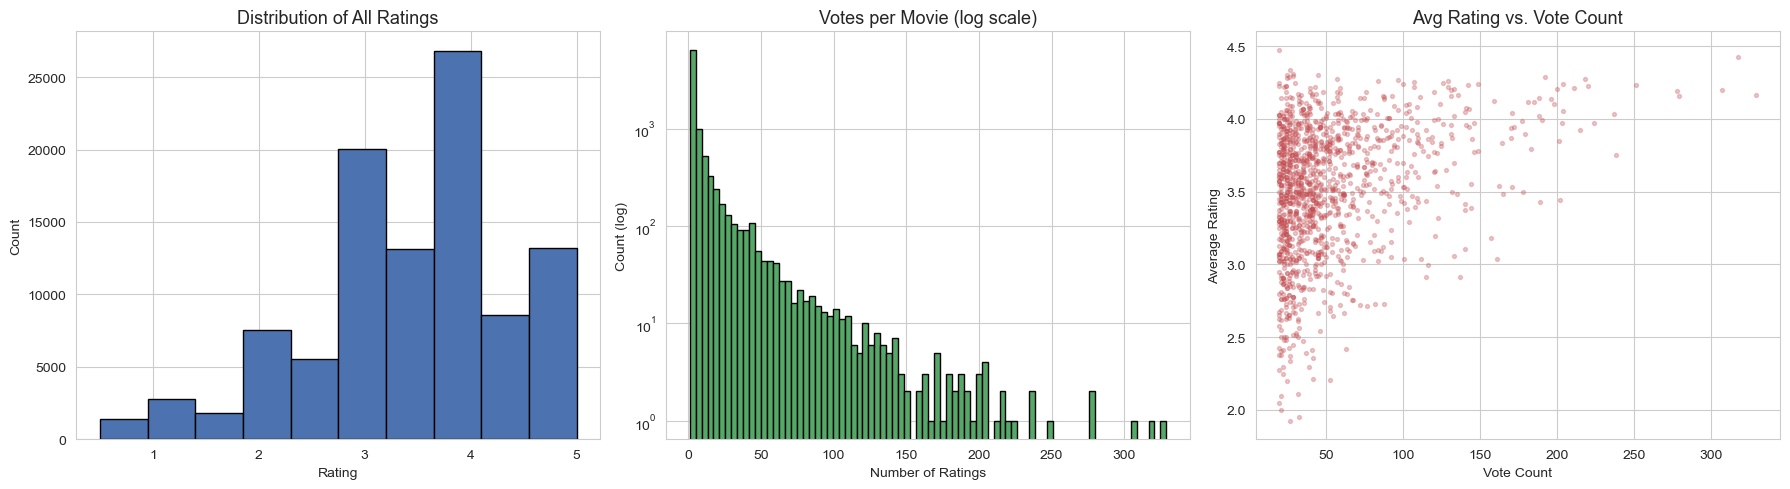

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating histogram
axes[0].hist(ratings["rating"], bins=10, edgecolor="black", color="#4C72B0")
axes[0].set_title("Distribution of All Ratings", fontsize=13)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Votes per movie (log)
vote_counts = movies["rating_count"]
axes[1].hist(vote_counts[vote_counts > 0], bins=80, edgecolor="black",
             color="#55A868", log=True)
axes[1].set_title("Votes per Movie (log scale)", fontsize=13)
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Count (log)")

# Avg rating vs vote count
sampled = movies[movies["rating_count"] >= 20].sample(
    min(3000, len(movies[movies["rating_count"] >= 20])), random_state=42
)
axes[2].scatter(sampled["rating_count"], sampled["rating_mean"],
                alpha=0.3, s=8, color="#C44E52")
axes[2].set_title("Avg Rating vs. Vote Count", fontsize=13)
axes[2].set_xlabel("Vote Count")
axes[2].set_ylabel("Average Rating")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}rating_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 7b — Genre Popularity

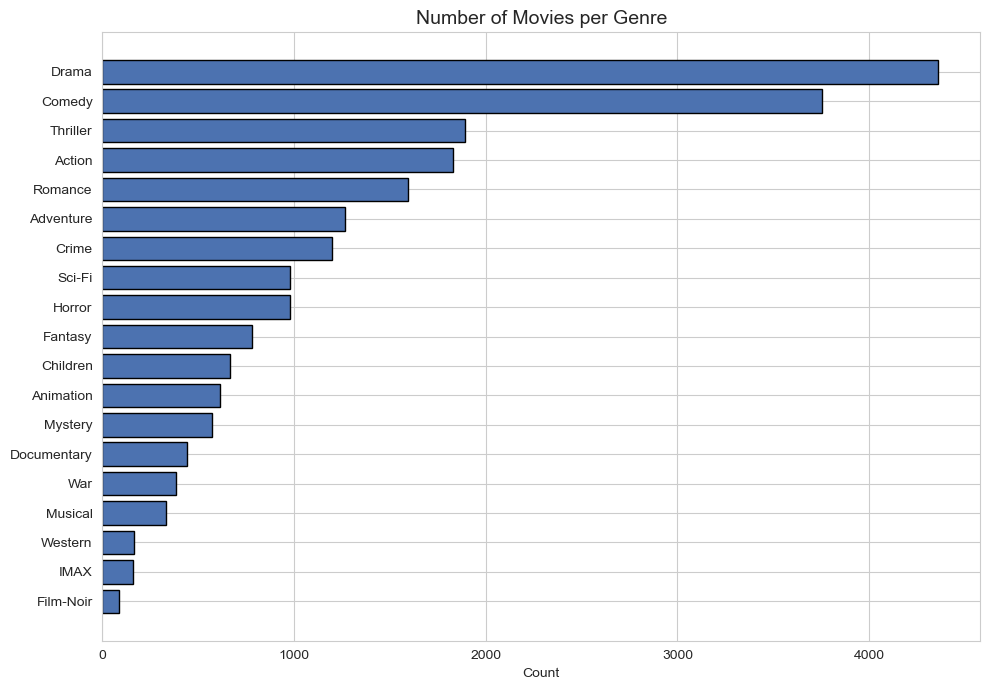

In [28]:
genre_counter = Counter(g for gl in movies["genre_list"] for g in gl)
genre_df = (
    pd.DataFrame(genre_counter.items(), columns=["Genre", "Count"])
    .sort_values("Count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(genre_df["Genre"], genre_df["Count"], color="#4C72B0", edgecolor="black")
ax.set_title("Number of Movies per Genre", fontsize=14)
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}genre_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

### 7c — Movies per Decade

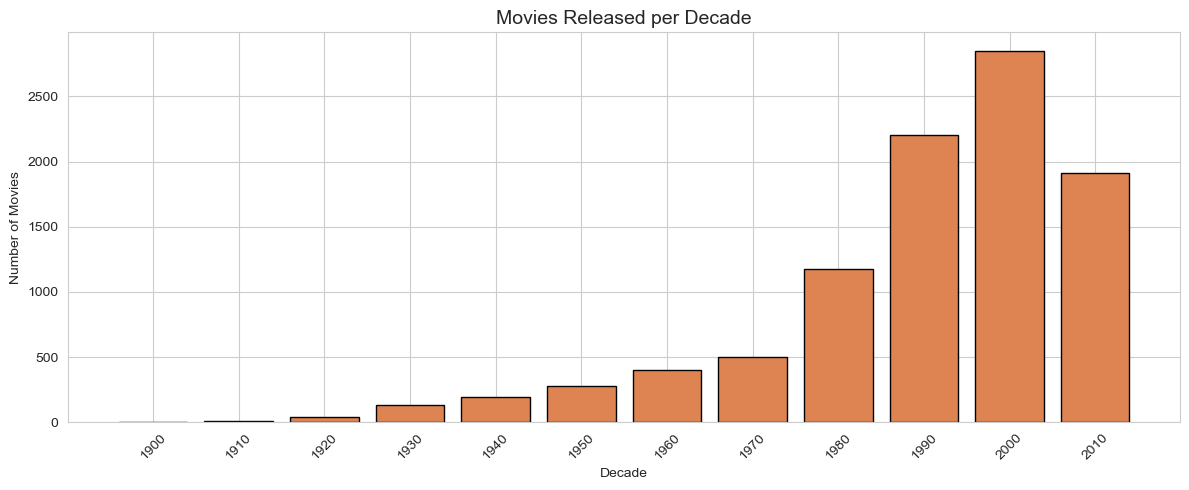

In [29]:
decade_counts = (
    movies.dropna(subset=["decade"])
    .groupby("decade").size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_counts["decade"].astype(str), decade_counts["count"],
       color="#DD8452", edgecolor="black")
ax.set_title("Movies Released per Decade", fontsize=14)
ax.set_xlabel("Decade")
ax.set_ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}movies_per_decade.png", dpi=150, bbox_inches="tight")
plt.show()

### 7d — Mean Rating vs. Bayesian Weighted Rating (Top 50)

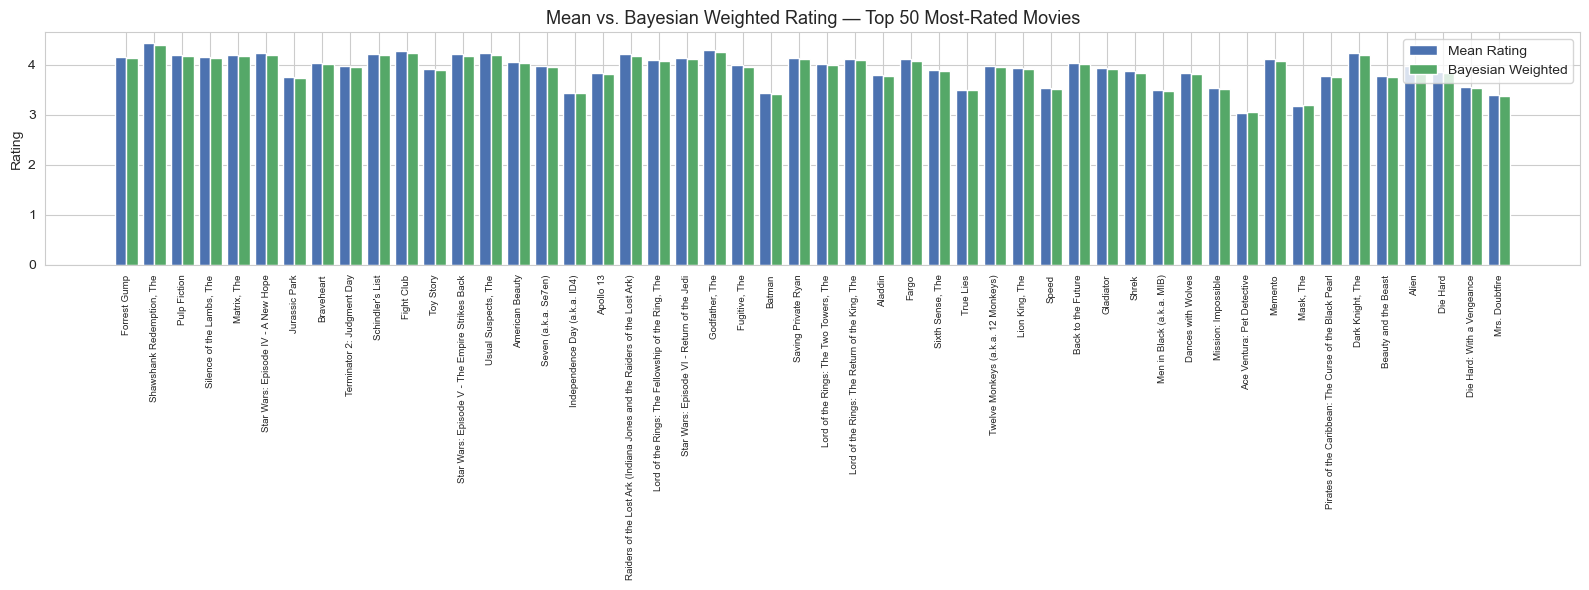

In [30]:
top50 = movies.nlargest(50, "rating_count")

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(top50))
ax.bar(x, top50["rating_mean"], width=0.4, label="Mean Rating",
       color="#4C72B0", align="center")
ax.bar([i + 0.4 for i in x], top50["weighted_rating"], width=0.4,
       label="Bayesian Weighted", color="#55A868", align="center")
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(top50["clean_title"], rotation=90, fontsize=7)
ax.set_title("Mean vs. Bayesian Weighted Rating — Top 50 Most-Rated Movies", fontsize=13)
ax.set_ylabel("Rating")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}mean_vs_weighted.png", dpi=150, bbox_inches="tight")
plt.show()

### 7e — Similarity Heatmap for Selected Movies

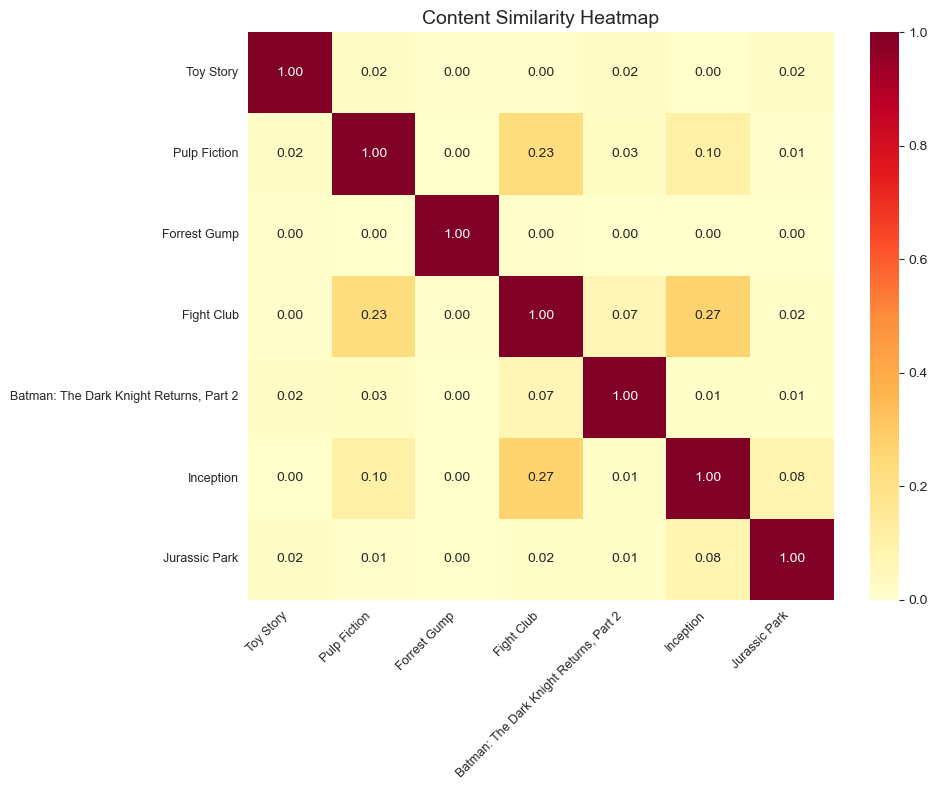

In [31]:
# Pick a handful of well-known movies for a cross-similarity heatmap
probe_titles = [
    "Toy Story", "The Matrix", "Pulp Fiction", "The Godfather",
    "Forrest Gump", "The Shawshank Redemption", "Fight Club",
    "The Dark Knight", "Inception", "Jurassic Park",
]

probe_indices = []
probe_labels  = []
for t in probe_titles:
    mask = movies["clean_title"].str.contains(t, case=False, na=False)
    match = movies[mask].sort_values("rating_count", ascending=False)
    if not match.empty:
        probe_indices.append(match.index[0])
        probe_labels.append(match.iloc[0]["clean_title"])

probe_matrix = tfidf_matrix[probe_indices]
sim_matrix = cosine_similarity(probe_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=probe_labels, yticklabels=probe_labels, ax=ax)
ax.set_title("Content Similarity Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 7f — Genre Co-occurrence Heatmap

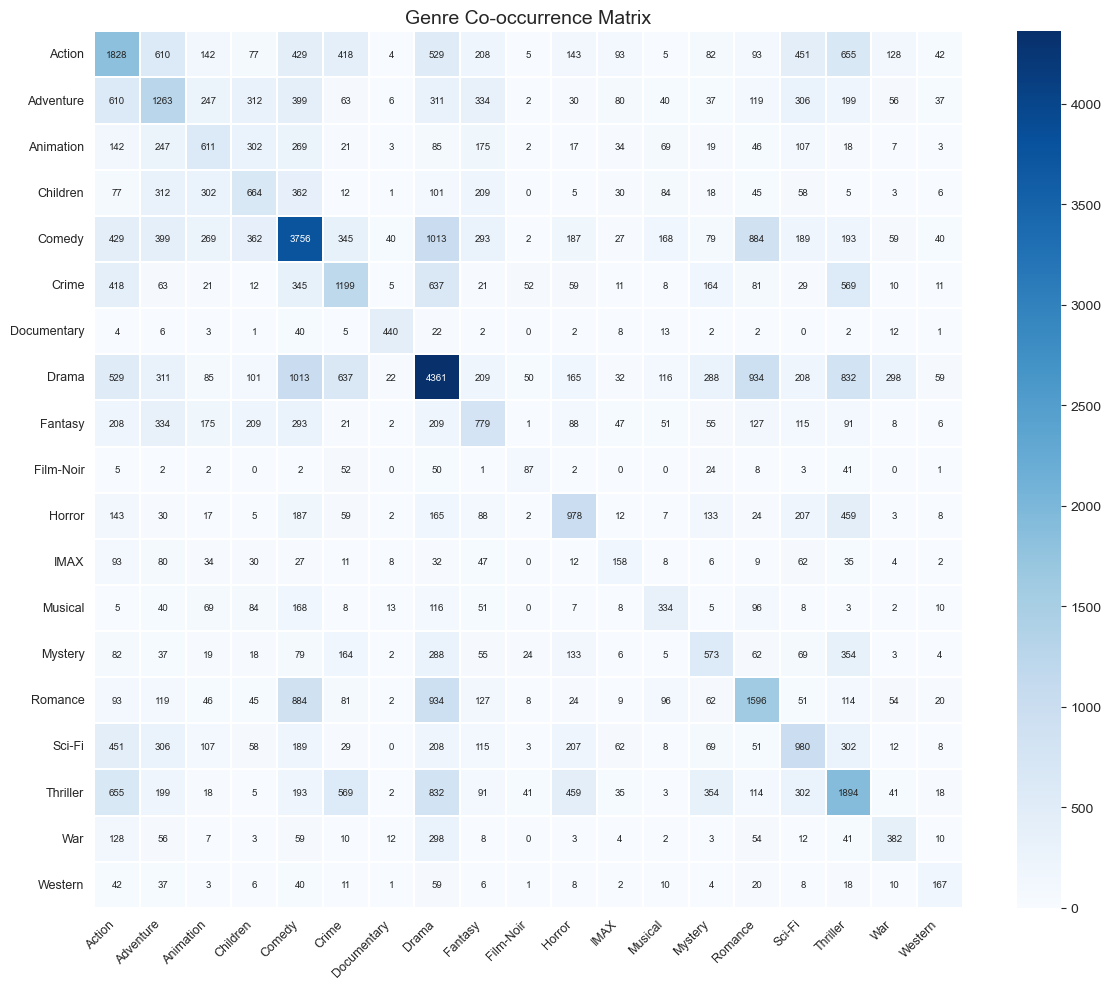

In [32]:
# Build genre co-occurrence matrix
genre_cooccurrence = pd.DataFrame(0, index=all_genres, columns=all_genres)
for gl in movies["genre_list"]:
    for i, g1 in enumerate(gl):
        for g2 in gl[i:]:
            genre_cooccurrence.loc[g1, g2] += 1
            if g1 != g2:
                genre_cooccurrence.loc[g2, g1] += 1

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(genre_cooccurrence, cmap="Blues", linewidths=0.3,
            fmt="d", annot=True, annot_kws={"size": 7}, ax=ax)
ax.set_title("Genre Co-occurrence Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}genre_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 8 — Interactive Demo

Use the `recommend()` function with any title. Try adjusting the weights and filters!

In [33]:
# ╔════════════════════════════════════════════════╗
# ║  TRY YOUR OWN QUERIES BELOW                   ║
# ╚════════════════════════════════════════════════╝

recommend("Inception", top_n=10)

▸ Source: Inception (2010)  (★ 4.07, 143 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,Donnie Darko,2001.0,Drama|Mystery|Sci-Fi|Thriller,3.981651,109,0.407259,0.810172
2,Arrival,2016.0,Sci-Fi,3.980769,26,0.428386,0.800696
3,Gattaca,1997.0,Drama|Sci-Fi|Thriller,3.953488,86,0.338096,0.664675
4,Eternal Sunshine of the Spotless Mind,2004.0,Drama|Romance|Sci-Fi,4.160305,131,0.312975,0.660240
5,Interstellar,2014.0,Sci-Fi|IMAX,3.993151,73,0.325396,0.637621
6,Fight Club,1999.0,Action|Crime|Drama|Thriller,4.272936,218,0.268623,0.629303
7,Primal Fear,1996.0,Crime|Drama|Mystery|Thriller,3.642857,35,0.324631,0.581674
8,Shutter Island,2010.0,Drama|Mystery|Thriller,4.022388,67,0.295200,0.579911
9,American History X,1998.0,Crime|Drama,4.217054,129,0.265873,0.575694
10,Doctor Strange,2016.0,Action|Adventure|Sci-Fi,3.704545,22,0.289483,0.511072


In [34]:
# Sci-Fi recommendations with quality emphasis
recommend("Interstellar", top_n=10, genre_filter="Sci-Fi", alpha=0.50, beta=0.35, gamma=0.15)

▸ Source: Interstellar (2014)  (★ 3.99, 73 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,Primer,2004.0,Drama|Sci-Fi,3.794118,17,0.666307,0.743954
2,Back to the Future,1985.0,Adventure|Comedy|Sci-Fi,4.038012,171,0.519809,0.717811
3,Stargate,1994.0,Action|Adventure|Sci-Fi,3.375000,140,0.562276,0.652602
4,Time Bandits,1981.0,Adventure|Comedy|Fantasy|Sci-Fi,3.731707,41,0.508474,0.595620
5,Back to the Future Part II,1989.0,Adventure|Comedy|Sci-Fi,3.505747,87,0.502995,0.584810
6,Bill & Ted's Excellent Adventure,1989.0,Adventure|Comedy|Sci-Fi,3.700000,45,0.496523,0.581812
7,Twelve Monkeys (a.k.a. 12 Monkeys),1995.0,Mystery|Sci-Fi|Thriller,3.983051,177,0.372338,0.560635
8,Inception,2010.0,Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,4.066434,143,0.325396,0.507590
9,Terminator 2: Judgment Day,1991.0,Action|Sci-Fi,3.970982,224,0.297105,0.503511
10,Star Trek,2009.0,Action|Adventure|Sci-Fi|IMAX,3.864407,59,0.332238,0.442375


In [35]:
# Classic comedies from the 90s
recommend("Home Alone", top_n=10, genre_filter="Comedy", year_from=1990, year_to=1999)

▸ Source: Home Alone (1990)  (★ 3.00, 116 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,"Sandlot, The",1993.0,Children|Comedy|Drama,3.437500,24,0.360400,0.319223
2,Matilda,1996.0,Children|Comedy|Fantasy,3.272727,33,0.304276,0.262088
3,"Muppet Christmas Carol, The",1992.0,Children|Comedy|Musical,3.736842,19,0.243813,0.240212
4,Harriet the Spy,1996.0,Children|Comedy,3.136364,11,0.268022,0.212123
5,Jingle All the Way,1996.0,Children|Comedy,2.861111,18,0.280713,0.203594
6,Antz,1998.0,Adventure|Animation|Children|Comedy|Fantasy,3.244444,45,0.219081,0.192538
7,"Borrowers, The",1997.0,Adventure|Children|Comedy|Fantasy,3.041667,12,0.247690,0.188655
8,Kazaam,1996.0,Children|Comedy|Fantasy,2.250000,12,0.304276,0.183651
9,Home Alone 2: Lost in New York,1992.0,Children|Comedy,2.516129,31,0.271530,0.167720
10,Hocus Pocus,1993.0,Children|Comedy|Fantasy|Horror,2.760870,23,0.239260,0.160458


In [36]:
# Horror with low min_votes to surface hidden gems
recommend("The Shining", top_n=10, genre_filter="Horror", min_votes=5)

▸ Source: The Shining (1997)  (★ 2.00, 1 votes)


,Title,Year,Genres,Avg Rating,Votes,Similarity,Hybrid Score
1,Thesis (Tesis),1996.0,Drama|Horror|Thriller,3.900000,5,0.686524,0.759193
2,1408,2007.0,Drama|Horror|Thriller,3.160000,25,0.686524,0.731590
3,Daybreakers,2010.0,Action|Drama|Horror|Thriller,3.416667,6,0.573746,0.587463
4,Gothika,2003.0,Horror|Thriller,3.111111,9,0.514337,0.492406
5,Firestarter,1984.0,Horror|Thriller,3.050000,10,0.514337,0.488629
6,Ravenous,1999.0,Horror|Thriller,3.000000,8,0.514337,0.486121
7,Thinner,1996.0,Horror|Thriller,2.818182,11,0.514337,0.473515
8,Cursed,2005.0,Horror|Thriller,2.166667,6,0.514337,0.446335
9,Split,2017.0,Drama|Horror|Thriller,3.333333,6,0.463243,0.434912
10,"Cell, The",2000.0,Drama|Horror|Thriller,3.044444,45,0.463243,0.429184


---
## Summary

| Component | Detail |
|-----------|--------|
| **Similarity** | TF-IDF (10k features, bigrams) + cosine similarity |
| **Quality signal** | Bayesian weighted rating (IMDB formula) |
| **Popularity signal** | Min-max normalised vote count |
| **Hybrid score** | α·content + β·quality + γ·popularity |
| **Filters** | Year range, genre, minimum votes |

### Next Steps / Extensions
- Add **collaborative filtering** (user-item matrix factorisation)
- Incorporate **genome scores** for richer tag features
- Build a **Streamlit / Gradio** web app for a polished UI
- Evaluate with **precision@k** and **nDCG** on a held-out test set
- Add **temporal decay** to penalise very old ratings